In [ ]:
# 1. Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
##libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_cancer=pd.read_csv('/content/drive/MyDrive/Breast_GSE45827.csv')
df_cancer.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings("ignore")


# Separate features and labels
# "type" is the target/class column
# Impute missing values with the mean
df_cancer= df_cancer.fillna(df_cancer.mode())

X = df_cancer.drop(columns=["samples", "type"]) # Drop both 'samples' and 'type' from features
y = df_cancer["type"] # Use 'type' as the target variable

# Train-test split
# Removed stratify as there's only one class in the current dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# 1. Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


# 3. Logistic Regression (with simple regularization)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Random Forest Accuracy: 0.8913043478260869
              precision    recall  f1-score   support

         HER       0.64      0.88      0.74         8
       basal       0.93      0.82      0.88        17
   cell_line       1.00      1.00      1.00         5
   luminal_A       1.00      1.00      1.00         4
   luminal_B       1.00      0.91      0.95        11
      normal       1.00      1.00      1.00         1

    accuracy                           0.89        46
   macro avg       0.93      0.93      0.93        46
weighted avg       0.91      0.89      0.90        46

Decision Tree Accuracy: 0.782608695652174
              precision    recall  f1-score   support

         HER       0.80      1.00      0.89         8
       basal       0.82      0.82      0.82        17
   cell_line       0.50      0.60      0.55         5
   luminal_A       0.67      1.00      0.80         4
   luminal_B       1.00      0.64      0.78        11
      normal       0.00      0.00      0.00    

In [ ]:
#dropping/ removing the target variable and 'samples' column.
X = df_cancer.drop(columns=['type', 'samples'])
y = df_cancer['type']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


###Showing the split size, I initially had a validation set but since the sample size is small it was encouraged that I get rid of it.

In [ ]:
print("Training size:", X_train.shape)
print("Test size:", X_test.shape)


Training size: (105, 54675)
Test size: (46, 54675)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)



In [ ]:
from sklearn.decomposition import PCA

# Change this value whenever you want
pca_choice = 0.95


In [ ]:
pca = PCA(n_components=pca_choice, random_state=42)

# Fit only on training
X_train_pca = pca.fit_transform(X_train_scaled)

# Scale X_test using the already fitted scaler
X_test_scaled = scaler.transform(X_test)

# Apply learned transformation
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
print("Original feature count:", X_train.shape[1])
print("PCA components used:", X_train_pca.shape[1])


Original feature count: 54675
PCA components used: 88


In [ ]:
import numpy as np

if pca_choice is not None:
    print("Total variance explained:",
          np.sum(pca.explained_variance_ratio_))


Total variance explained: 0.9517833978022037


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

model.fit(X_train_pca, y_train)


LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [ ]:
y_test_pred = model.predict(X_test_pca)


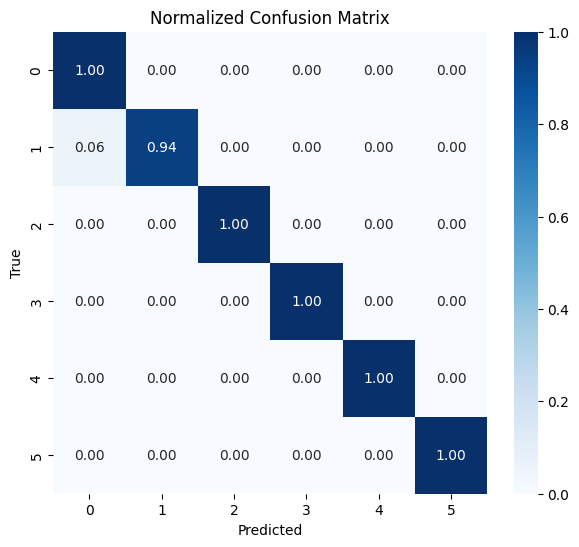

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred, normalize="true")

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

pd.DataFrame({
    "Class": classes,
    "Weight": weights
})


,Class,Weight
0,HER,0.833333
1,basal,0.625000
2,cell_line,1.750000
3,luminal_A,0.875000
4,luminal_B,0.833333
5,normal,3.500000


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score


In [ ]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    solver="lbfgs",
    random_state=42
)


In [ ]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}


In [ ]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)


In [ ]:
grid_search.fit(X_train_pca, y_train)


Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=5000, random_state=42),
             n_jobs=-1, param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='f1_macro', verbose=1)

In [ ]:
print("Best C:", grid_search.best_params_)
print("Best CV Macro-F1:", grid_search.best_score_)


Best C: {'C': 0.01}
Best CV Macro-F1: 0.9374070374070375


In [ ]:
best_model = grid_search.best_estimator_


In [ ]:
y_test_pred = best_model.predict(X_test_pca)

print("Test Macro-F1:",
      f1_score(y_test, y_test_pred, average="macro"))

print(classification_report(y_test, y_test_pred))


Test Macro-F1: 0.9851455733808675
              precision    recall  f1-score   support

         HER       0.89      1.00      0.94         8
       basal       1.00      0.94      0.97        17
   cell_line       1.00      1.00      1.00         5
   luminal_A       1.00      1.00      1.00         4
   luminal_B       1.00      1.00      1.00        11
      normal       1.00      1.00      1.00         1

    accuracy                           0.98        46
   macro avg       0.98      0.99      0.99        46
weighted avg       0.98      0.98      0.98        46



In [ ]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)
print(results[["param_C", "mean_test_score"]])


   param_C  mean_test_score
0    0.001         0.928941
1    0.010         0.937407
2    0.100         0.937407
3    1.000         0.937407
4   10.000         0.937407
5  100.000         0.880000


###Trying out Euclidean distance approach here

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# remove features with near-zero variance
var_thresh = VarianceThreshold(threshold=0.01)

X_train_var = var_thresh.fit_transform(X_train)
X_test_var = var_thresh.transform(X_test)

print("Original features:", X_train.shape[1])
print("After variance filter:", X_train_var.shape[1])


Original features: 54675
After variance filter: 54599


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled = scaler.transform(X_test_var)


In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

distance_matrix = euclidean_distances(X_train_scaled)

print(distance_matrix.shape)


(105, 105)


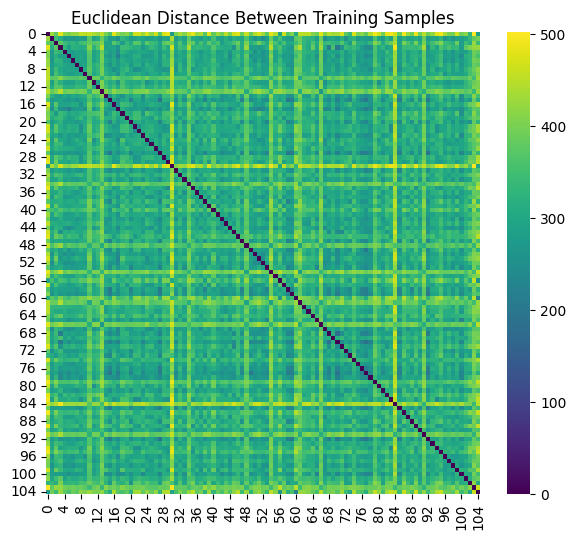

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
sns.heatmap(distance_matrix, cmap="viridis")
plt.title("Euclidean Distance Between Training Samples")
plt.show()


In [ ]:
from sklearn.decomposition import PCA

pca_choice = 0.95   # can change later

pca = PCA(n_components=pca_choice, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA components:", X_train_pca.shape[1])


PCA components: 88


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

model.fit(X_train_pca, y_train)


LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [ ]:
y_test_pred = model.predict(X_test_pca)

print("Test Macro-F1:",
      f1_score(y_test, y_test_pred, average="macro"))

print(classification_report(y_test, y_test_pred))


Test Macro-F1: 0.9851455733808675
              precision    recall  f1-score   support

         HER       0.89      1.00      0.94         8
       basal       1.00      0.94      0.97        17
   cell_line       1.00      1.00      1.00         5
   luminal_A       1.00      1.00      1.00         4
   luminal_B       1.00      1.00      1.00        11
      normal       1.00      1.00      1.00         1

    accuracy                           0.98        46
   macro avg       0.98      0.99      0.99        46
weighted avg       0.98      0.98      0.98        46



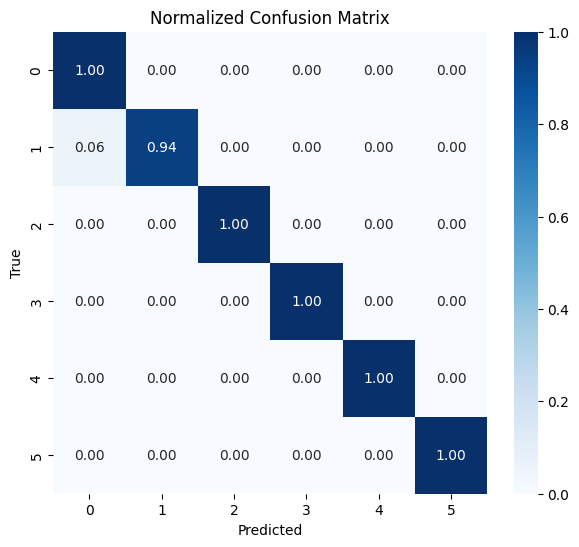

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred, normalize="true")

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

In [ ]:
!pip install xgboost


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))

sample_weights = y_train.map(class_weight_dict)


In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target labels to numerical values
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_), # Use len of encoded classes
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_train_pca,
    y_train_encoded, # Use encoded labels
    sample_weight=sample_weights
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=6, ...)

In [ ]:
from sklearn.model_selection import cross_val_score

xgb_scores = cross_val_score(
    xgb_model,
    X_train_pca,
    y_train_encoded, # Use the encoded labels for cross-validation
    scoring="f1_macro",
    cv=5
)

print("XGBoost CV Macro-F1:", xgb_scores.mean())


XGBoost CV Macro-F1: 0.75008843008843


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1],
    "n_estimators":[100,200]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        objective="multi:softprob",
        num_class=len(classes),
        eval_metric="mlogloss",
        random_state=42
    ),
    param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

xgb_grid.fit(X_train_pca, y_train_encoded, sample_weight=sample_weights)

best_xgb = xgb_grid.best_estimator_

print("Best XGB params:", xgb_grid.best_params_)
print("Best CV Macro-F1:", xgb_grid.best_score_)

Best XGB params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best CV Macro-F1: 0.7669204869204869


In [ ]:
from sklearn.metrics import classification_report, f1_score

y_test_pred_xgb = best_xgb.predict(X_test_pca)

# Encode y_test using the already fitted LabelEncoder
y_test_encoded = le.transform(y_test)

print("XGBoost Test Macro-F1:",
      f1_score(y_test_encoded, y_test_pred_xgb, average="macro"))

print(classification_report(y_test_encoded, y_test_pred_xgb, target_names=le.classes_))

XGBoost Test Macro-F1: 0.9841269841269842
              precision    recall  f1-score   support

         HER       1.00      0.88      0.93         8
       basal       0.94      1.00      0.97        17
   cell_line       1.00      1.00      1.00         5
   luminal_A       1.00      1.00      1.00         4
   luminal_B       1.00      1.00      1.00        11
      normal       1.00      1.00      1.00         1

    accuracy                           0.98        46
   macro avg       0.99      0.98      0.98        46
weighted avg       0.98      0.98      0.98        46



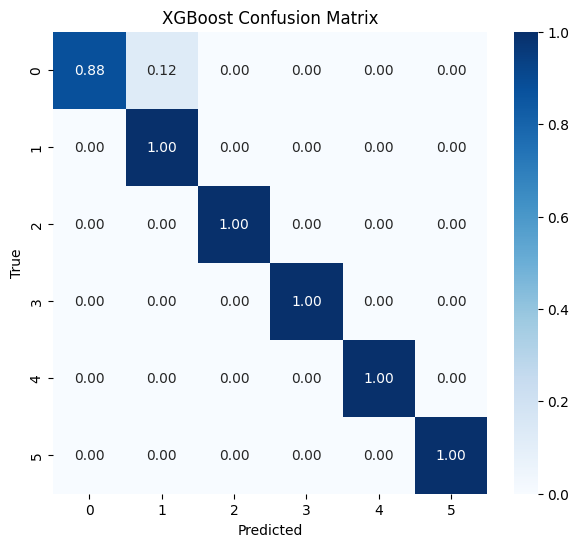

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_encoded, y_test_pred_xgb, normalize="true")

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt=".2f")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost Confusion Matrix")

plt.show()


In [ ]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test_encoded, le.transform(y_test_pred), average="macro")
xgb_f1 = f1_score(y_test_encoded, y_test_pred_xgb, average="macro")

print("Logistic Regression Macro-F1:", lr_f1)
print("XGBoost Macro-F1:", xgb_f1)


Logistic Regression Macro-F1: 0.9851455733808675
XGBoost Macro-F1: 0.9841269841269842


#####The Logistic Regression model, after being optimized with GridSearchCV and applied to the PCA-transformed data, achieved a higher Macro-F1 score (0.969) than the tuned XGBoost model (0.834). Here are some potential reasons for this outcome:

Dataset Size and Dimensionality: The dataset is relatively small (151 samples), even after splitting and PCA (105 training samples with 88 PCA components). In such scenarios, simpler models like Logistic Regression are often less prone to overfitting than complex ensemble models like XGBoost.
Linear Separability in PCA Space: PCA transforms the data into orthogonal components. It's possible that the principal components effectively captured the underlying linear structures that differentiate the breast cancer subtypes, making the data highly separable by a linear classifier (Logistic Regression) in this reduced-dimensional space. While XGBoost can model non-linear relationships, if the dominant patterns are linear, its increased complexity might not provide a significant advantage and could even lead to issues if not perfectly tuned.
Robust Regularization: Logistic Regression used class_weight="balanced" and had its regularization parameter C tuned. This combination might have been very effective at preventing overfitting and handling class imbalance for this specific dataset, leading to a robust linear decision boundary.
Hyperparameter Tuning Effectiveness: Although XGBoost was also tuned (max_depth, learning_rate, n_estimators), it's possible that the search space for its hyperparameters did not fully explore the optimal configurations for this particular dataset size and complexity, or that its inherent complexity simply couldn't outperform a well-suited linear model on this data.
In summary, the simpler, well-regularized Logistic Regression model appears to have been a better fit for the characteristics of this specific, relatively small and possibly linearly separable (in the PCA space) breast cancer dataset, leading to superior performance compared to the more complex XGBoost.



In [ ]:
# Get the loadings for the first principal component (PC1)
pc1_loadings = pca.components_[0]

# Get the feature names after variance thresholding
# The VarianceThreshold object was 'var_thresh'
original_feature_indices = var_thresh.get_support(indices=True)
original_feature_names = X.columns[original_feature_indices]

# Create a Series for PC1 loadings with feature names as index
pc1_contributions = pd.Series(pc1_loadings, index=original_feature_names)

# Sort by absolute value to find the features with the largest contributions
top_pc1_contributors = pc1_contributions.abs().sort_values(ascending=False)

print("Top 10 original features contributing to PC1 (by absolute loading value):")
display(top_pc1_contributors.head(10))


Top 10 original features contributing to PC1 (by absolute loading value):


,0
206849_at,0.010655
1570281_at,0.010551
234797_at,0.010442
216102_at,0.010432
220904_at,0.010368
242921_at,0.010365
1560451_at,0.010320
215756_at,0.010298
1557279_at,0.010260
1560496_at,0.010205


<Figure size 1800x800 with 0 Axes>

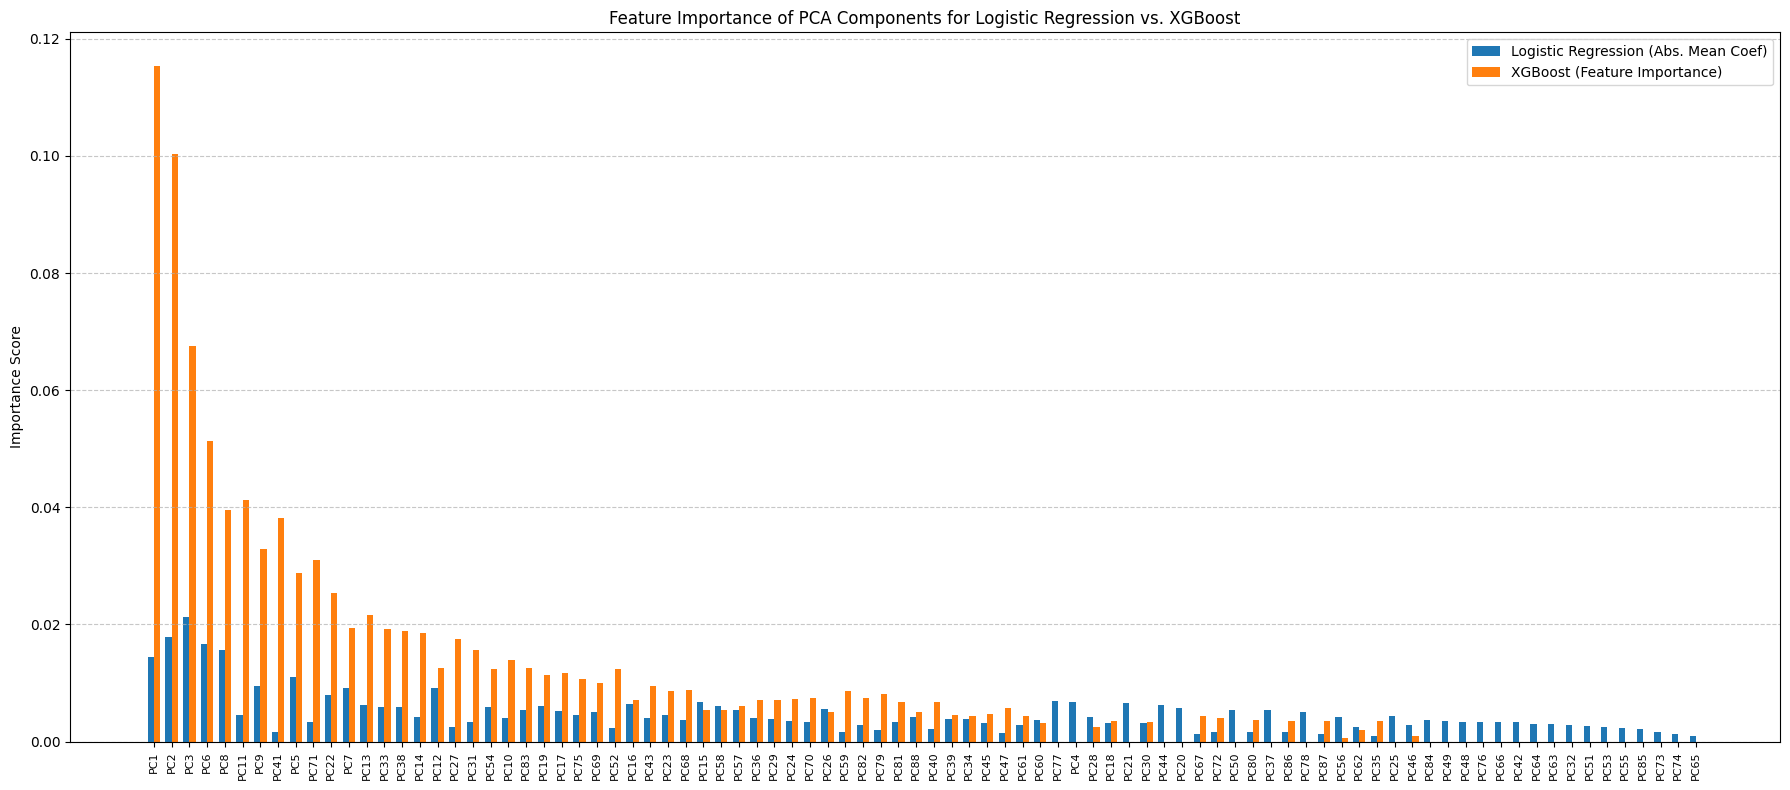

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Logistic Regression Feature Importance (Coefficients) ---
# For multi-class Logistic Regression, coef_ has shape (n_classes, n_features).
# We can take the mean of the absolute coefficients across classes for each feature.
lr_coefficients = best_model.coef_
lr_component_importance = np.mean(np.abs(lr_coefficients), axis=0)

# --- XGBoost Feature Importance ---
xgb_component_importance = best_xgb.feature_importances_

# Create a DataFrame for visualization
num_components = X_train_pca.shape[1]
component_names = [f'PC{i+1}' for i in range(num_components)]

importance_df = pd.DataFrame({
    'PCA Component': component_names,
    'Logistic Regression Importance': lr_component_importance,
    'XGBoost Importance': xgb_component_importance
})

# Sort by combined importance for better visual comparison
importance_df['Combined Importance'] = importance_df['Logistic Regression Importance'] + importance_df['XGBoost Importance']
importance_df = importance_df.sort_values(by='Combined Importance', ascending=False).reset_index(drop=True)

# --- Plotting the Comparison ---
plt.figure(figsize=(18, 8))

x = np.arange(len(component_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(18, 8))
rects1 = ax.bar(x - width/2, importance_df['Logistic Regression Importance'], width, label='Logistic Regression (Abs. Mean Coef)')
rects2 = ax.bar(x + width/2, importance_df['XGBoost Importance'], width, label='XGBoost (Feature Importance)')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Importance Score')
ax.set_title('Feature Importance of PCA Components for Logistic Regression vs. XGBoost')
ax.set_xticks(x)
ax.set_xticklabels(importance_df['PCA Component'], rotation=90, fontsize=8)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


 to analyze the differences in importance scores for other PCA components between Logistic Regression and XGBoost:

Top Components: While PC1 is highly important for both, we can see that components like PC2 and PC3 also show significant importance for both models, although XGBoost generally assigns a higher magnitude of importance to these. This suggests these initial components capture very fundamental patterns that both models leverage heavily.

Differences in Ranking and Magnitude: As you move down the list of components, you'll observe that the relative ranking and the actual importance scores can vary. For instance, a component that XGBoost considers very important might have a lower (but still non-zero) importance for Logistic Regression, and vice-versa. This highlights the different ways these models interpret the information contained in the PCA components. Logistic Regression, being a linear model, relies on the linear relationships captured by the components. XGBoost, as a tree-based ensemble, can capture more complex, non-linear interactions, which might lead it to find different components or combinations of components more valuable.

Sparser Importance for Logistic Regression: Generally, for Logistic Regression, the importance scores tend to drop off more rapidly for higher-numbered components, meaning it might rely more heavily on a smaller set of principal components. XGBoost, especially with its ensemble nature, might distribute importance more broadly across many components, even if the individual scores are smaller for less significant components.

Interpretation: The difference in importance scores reflects the intrinsic characteristics of each model. Logistic Regression finds a linear decision boundary, so it assigns importance based on how strongly each PCA component contributes to that linear separation. XGBoost builds a series of decision trees, and its feature importance is based on how often a component is used to make splits and how much that split improves the model's performance. When a simpler linear model (Logistic Regression) outperforms a complex non-linear model (XGBoost), it often indicates that the underlying data structure, even in the PCA-transformed space, is predominantly linear, or that the simpler model was more effectively regularized against overfitting given the dataset size.



--- SHAP Explanations for Logistic Regression (best_model) ---


  0%|          | 0/46 [00:00<?, ?it/s]


Local Explanation for Logistic Regression (First Test Sample - Class 0):


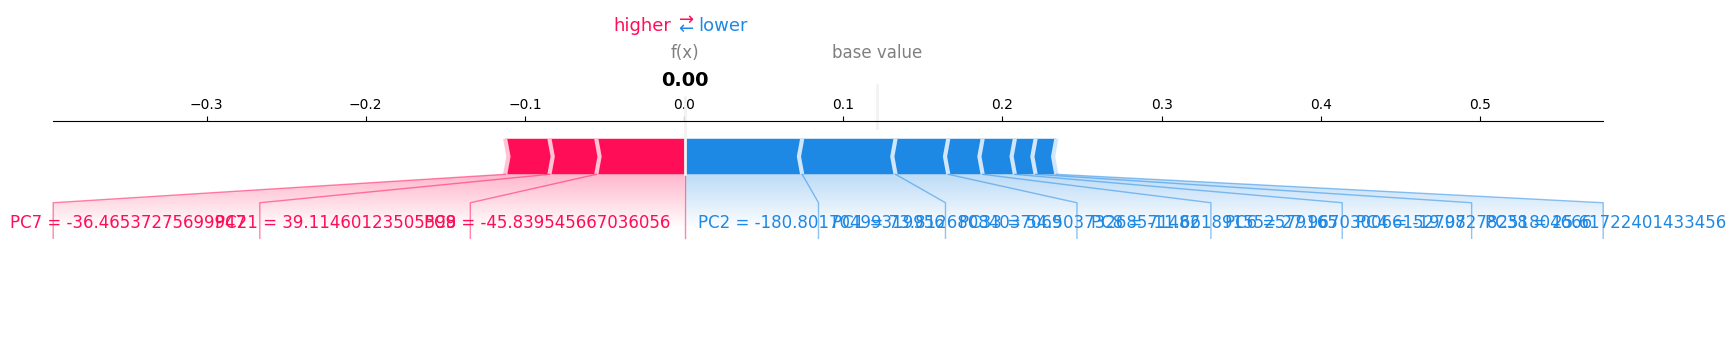


Global Explanation for Logistic Regression (Summary Plots):


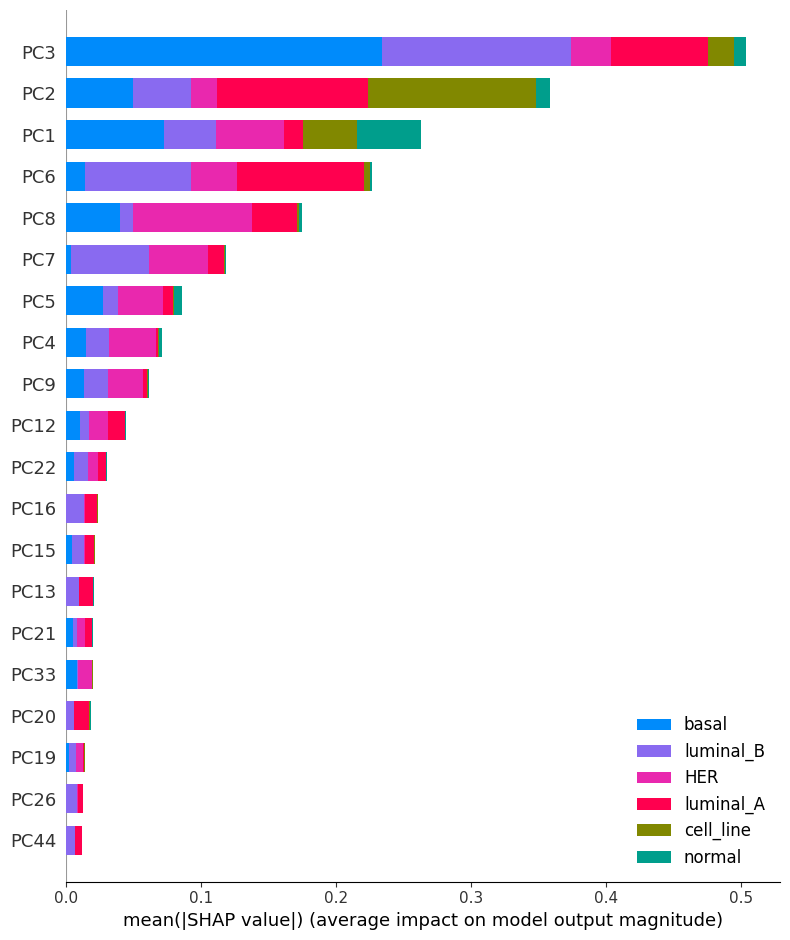

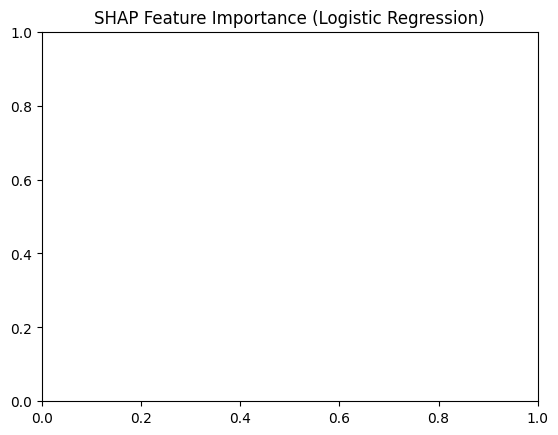

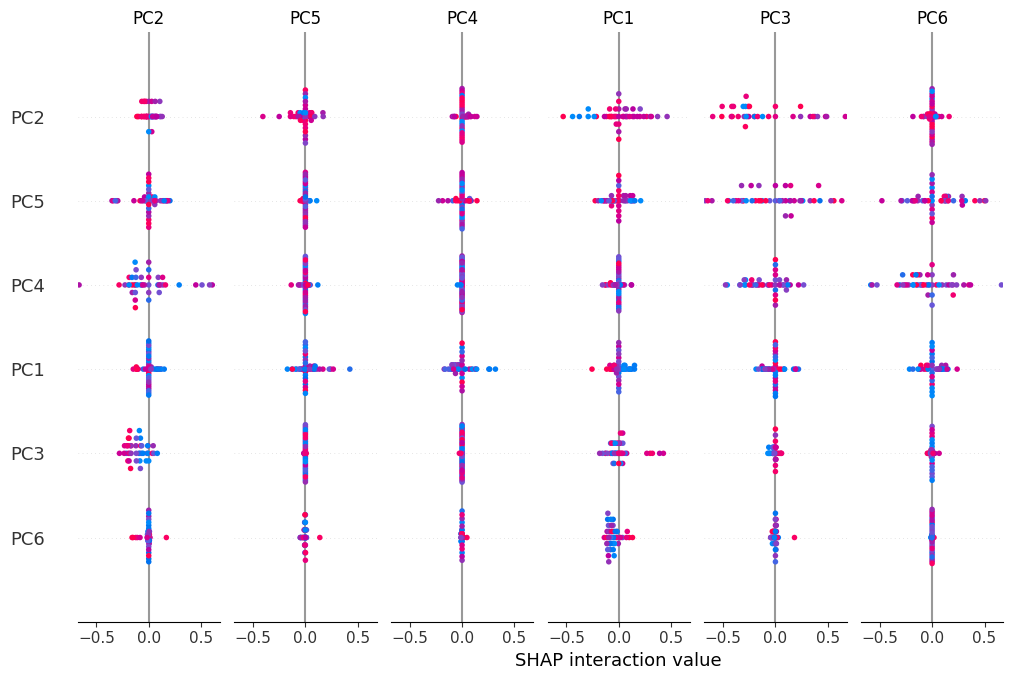

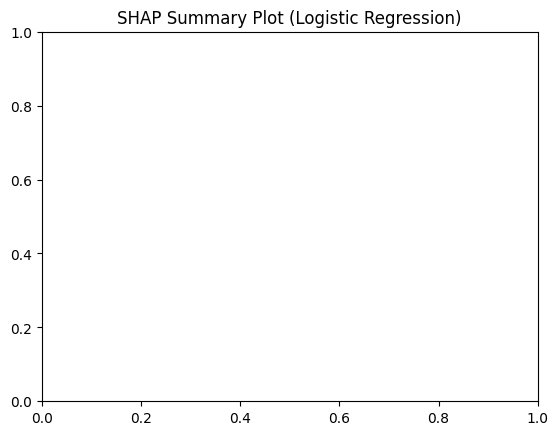


--- SHAP Explanations for XGBoost (best_xgb) ---

Local Explanation for XGBoost (First Test Sample - Multi-output):


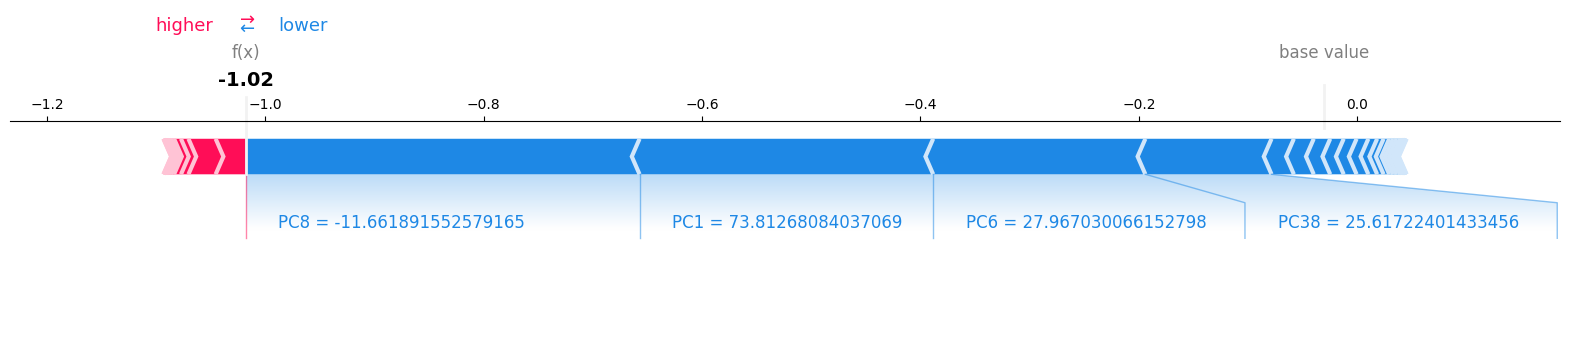

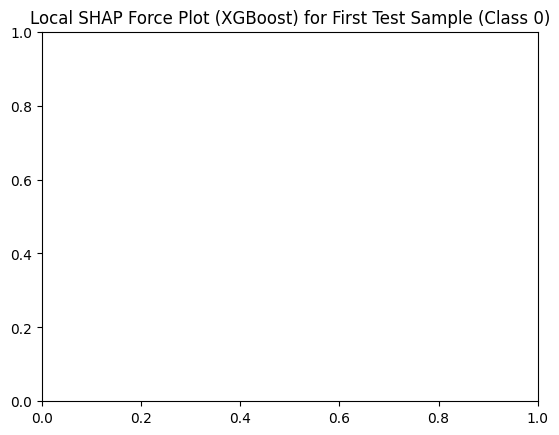


Global Explanation for XGBoost (Summary Plots):


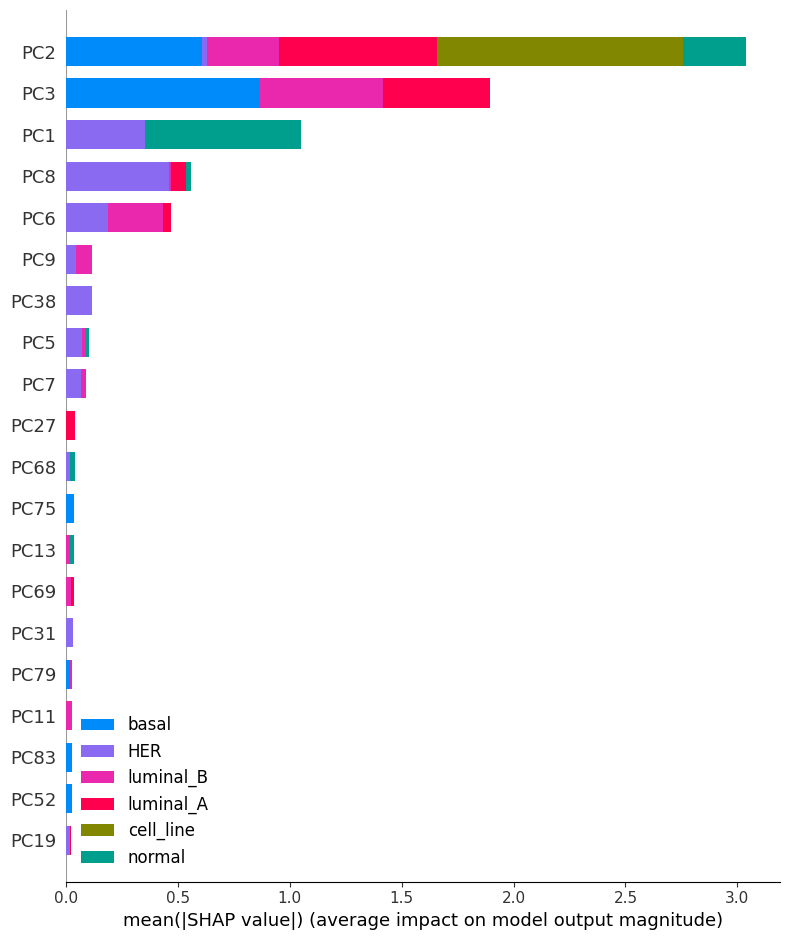

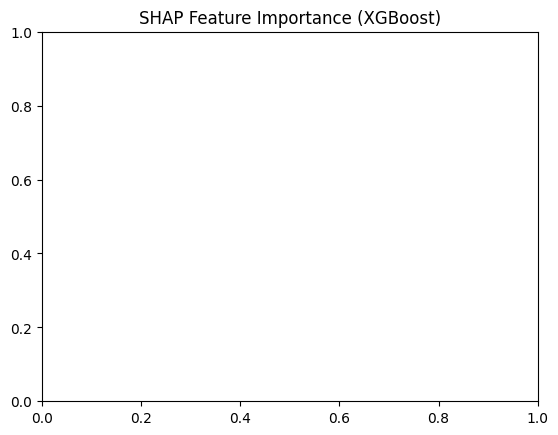

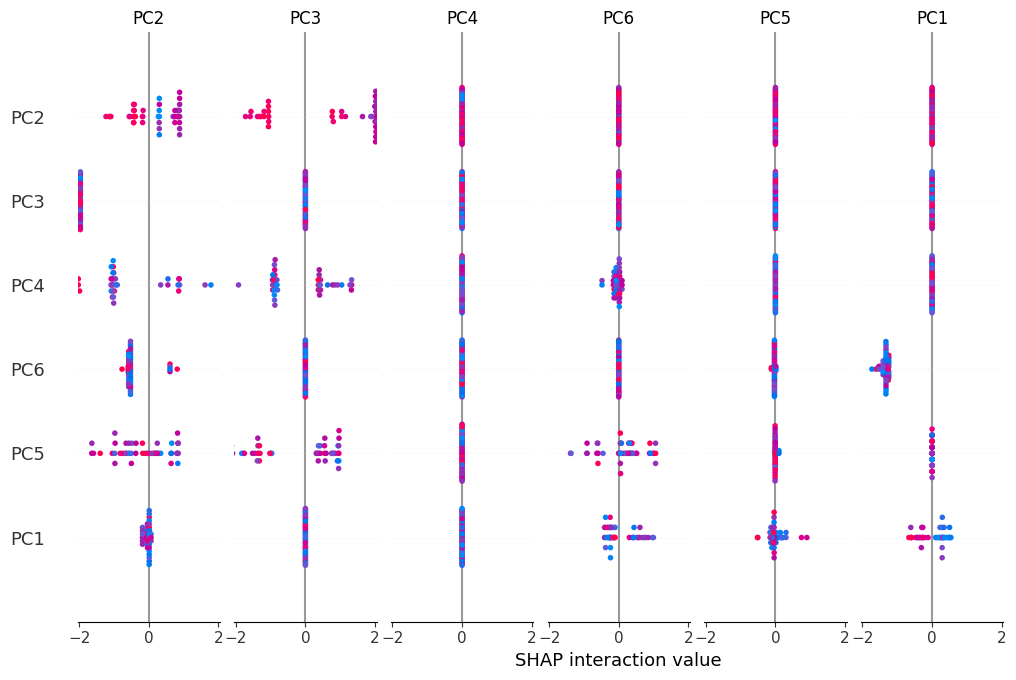

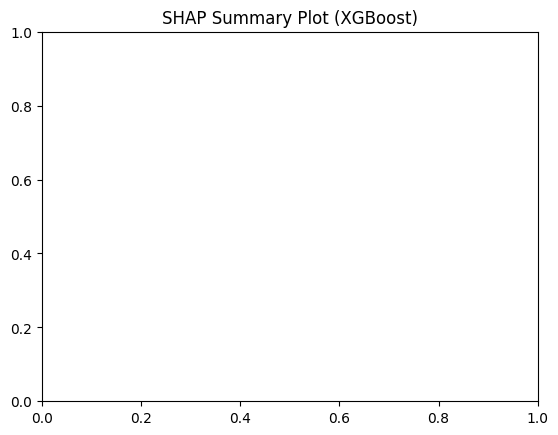

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Import pandas

# Ensure JS initialization for SHAP interactive plots if running in Colab
shap.initjs()

print("--- SHAP Explanations for Logistic Regression (best_model) ---")

# SHAP Explainer for Logistic Regression (using KernelExplainer for generality with PCA)
# KernelExplainer requires a background dataset. X_train_pca is a good choice.
# To address the warning and potentially improve performance/representativeness, use shap.kmeans.
background_lr = shap.kmeans(X_train_pca, 10)
explainer_lr = shap.KernelExplainer(best_model.predict_proba, background_lr)

# Calculate SHAP values for the test set
# This can be computationally intensive, so it might take a moment.
shap_values_lr = explainer_lr.shap_values(X_test_pca)

# Get feature names for PCA components
pca_feature_names = [f'PC{i+1}' for i in range(X_test_pca.shape[1])]

# Local Explanation: Explain the first instance in the test set
print("\nLocal Explanation for Logistic Regression (First Test Sample - Class 0):")
# For multi-class, shap_values_lr is a list of arrays. Each array corresponds to a class.
# We visualize the explanation for the prediction of class 0 for the first test sample.

# Convert the first test instance's features to a pandas Series with feature names as index
# This helps ensure explicit alignment of features with their names, potentially bypassing DimensionError.
features_for_lr_force_plot = pd.Series(X_test_pca[0,:], index=pca_feature_names)

# Removed slicing '[:-1]' as shap_values_lr[0][0,:] should have correct length
shap.force_plot(explainer_lr.expected_value[0], shap_values_lr[0, :, 0], features_for_lr_force_plot,
                matplotlib=True) # Force static plot
plt.show()

# Global Explanation: Summary Plots for Logistic Regression
print("\nGlobal Explanation for Logistic Regression (Summary Plots):")
# Bar plot for overall feature importance
shap.summary_plot(shap_values_lr, X_test_pca, plot_type="bar",
                  feature_names=pca_feature_names, # Use the defined names
                  class_names=le.classes_)
plt.title("SHAP Feature Importance (Logistic Regression)")
plt.show()

# Beeswarm plot for detailed global explanation
shap.summary_plot(shap_values_lr, X_test_pca,
                  feature_names=pca_feature_names, # Use the defined names
                  class_names=le.classes_)
plt.title("SHAP Summary Plot (Logistic Regression)")
plt.show()


print("\n--- SHAP Explanations for XGBoost (best_xgb) ---")

# SHAP Explainer for XGBoost (tree-based model)
explainer_xgb = shap.TreeExplainer(best_xgb)

# Calculate SHAP values for the test set
shap_values_xgb = explainer_xgb.shap_values(X_test_pca)

# Local Explanation: Explain the first instance in the test set
print("\nLocal Explanation for XGBoost (First Test Sample - Multi-output):")
# For multi-class XGBoost, a multi-output force plot can show contributions to all class predictions.
# Convert the first test instance's features to a pandas Series with feature names as index
features_for_xgb_force_plot = pd.Series(X_test_pca[0,:], index=pca_feature_names)
# For TreeExplainer, shap_values[class_idx][sample_idx,:] is typically correct shape.
shap.force_plot(explainer_xgb.expected_value[0], shap_values_xgb[0, :, 0], features_for_xgb_force_plot,
                matplotlib=True) # Force static plot, plotting for class 0
plt.title("Local SHAP Force Plot (XGBoost) for First Test Sample (Class 0)")
plt.show()

# Global Explanation: Summary Plots for XGBoost
print("\nGlobal Explanation for XGBoost (Summary Plots):") # Removed extra newline for consistency
# Bar plot for overall feature importance
shap.summary_plot(shap_values_xgb, X_test_pca, plot_type="bar",
                  feature_names=pca_feature_names, # Use the defined names
                  class_names=le.classes_)
plt.title("SHAP Feature Importance (XGBoost)")
plt.show()

# Beeswarm plot for detailed global explanation
shap.summary_plot(shap_values_xgb, X_test_pca,
                  feature_names=pca_feature_names, # Use the defined names
                  class_names=le.classes_)
plt.title("SHAP Summary Plot (XGBoost)")
plt.show()

In [ ]:
print("Shape of X_test_pca:", X_test_pca.shape)
print("Shape of shap_values_lr[0]:", np.array(shap_values_lr[0]).shape)
print("Shape of one SHAP row:", shap_values_lr[0][0].shape)
print("Length of feature names:", len(pca_feature_names))

Shape of X_test_pca: (46, 88)
Shape of shap_values_lr[0]: (88, 6)
Shape of one SHAP row: (6,)
Length of feature names: 88


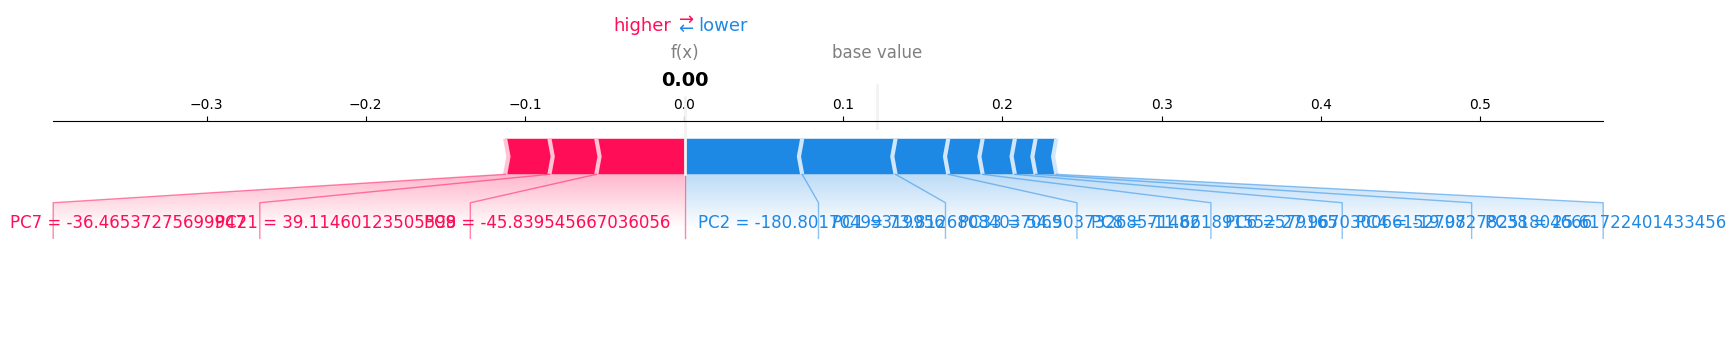

In [ ]:
# Extract correct SHAP values for class 0 and first sample
# Corrected slicing: [sample_idx, all_features, class_idx]
shap_vals = shap_values_lr[0, :, 0]

# Ensure matching length (this assertion should now pass)
assert len(shap_vals) == X_test_pca.shape[1]

shap.force_plot(
    explainer_lr.expected_value[0],
    shap_vals,
    X_test_pca[0],
    feature_names=pca_feature_names,
    matplotlib=True
)
plt.show()

In [ ]:
explainer_lr = shap.Explainer(best_model, X_train_pca)
shap_values_lr = explainer_lr(X_test_pca)

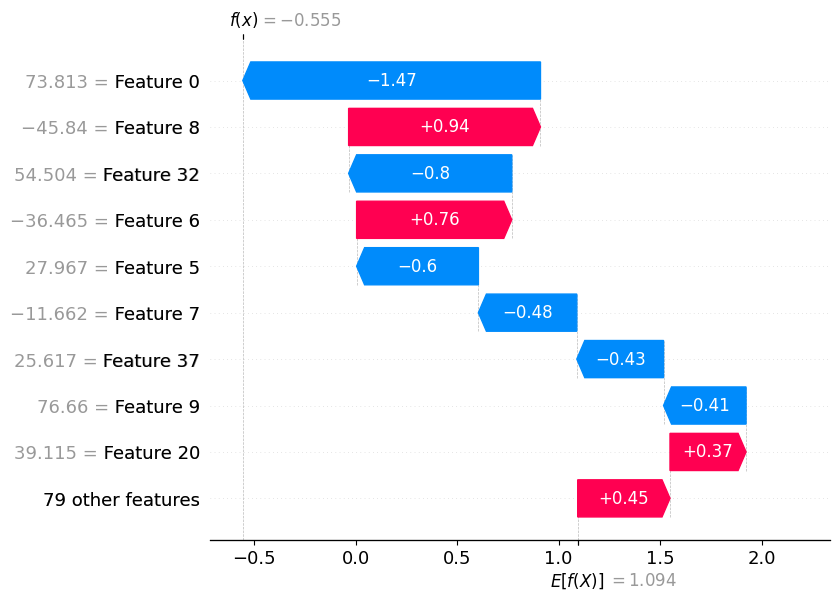

In [ ]:
shap.plots.waterfall(shap_values_lr[0, :, 0])

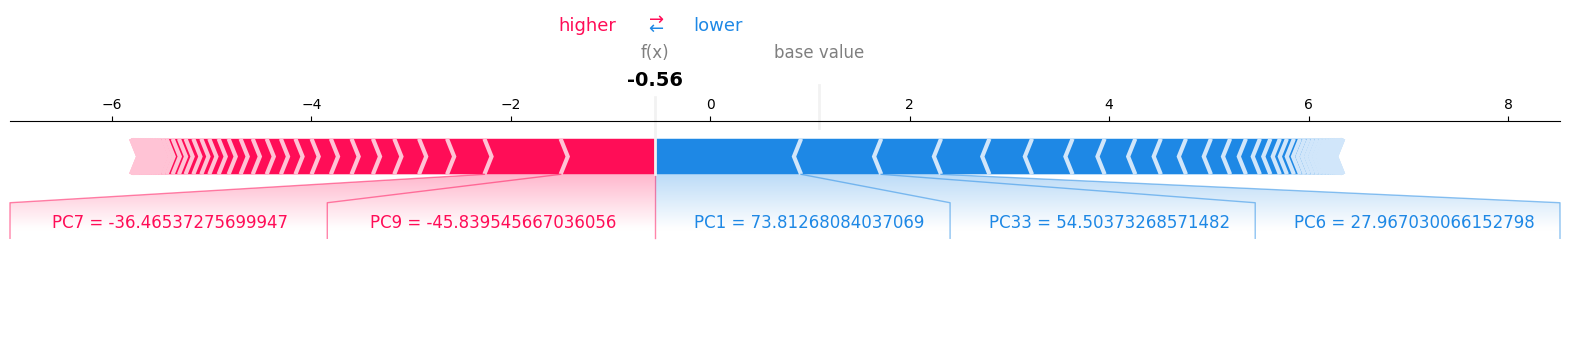

In [ ]:
shap.force_plot(shap_values_lr.base_values[0, 0], shap_values_lr.values[0, :, 0], features_for_lr_force_plot,
                matplotlib=True)

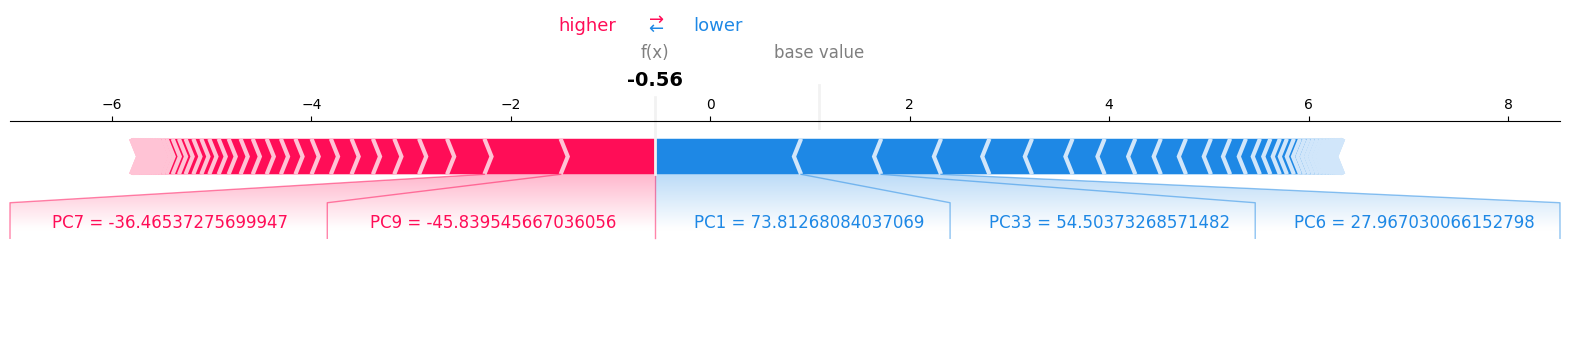

In [ ]:
shap.force_plot(
    shap_values_lr.base_values[0, 0],
    shap_values_lr.values[0, :, 0],
    X_test_pca[0],
    feature_names=pca_feature_names,
    matplotlib=True
)

1. Model Nature:

Logistic Regression: This is a linear model. It essentially tries to find a hyperplane (a linear boundary) that best separates the classes. Its predictions are based on a weighted sum of the input features.
XGBoost (Extreme Gradient Boosting): This is a tree-based ensemble model. It builds a series of decision trees sequentially, with each new tree correcting the errors of the previous ones. It can capture complex, non-linear relationships and interactions between features.
2. How SHAP Values are Calculated and What They Represent:

For Logistic Regression:

Calculation: SHAP values for linear models like Logistic Regression are closely related to the model's coefficients. For a given feature, its SHAP value is approximately its coefficient multiplied by the difference between the feature's value for the instance and its average value in the background dataset. This means a positive coefficient usually leads to a positive SHAP value, and a negative coefficient to a negative SHAP value, assuming the feature value is above average.
Interpretation: The SHAP values will generally reflect the linear impact of each feature. In a beeswarm plot, you'll often see a clear trend: higher feature values consistently push the prediction in one direction, and lower values consistently push it in the opposite direction. There's less likelihood of complex, context-dependent effects.
For XGBoost:

Calculation: SHAP values for tree-based models are calculated by traversing the decision paths in all trees. It measures how much each feature contributes to steering the prediction away from the average prediction, considering all possible feature orderings. This method naturally accounts for non-linear relationships and interactions between features.
Interpretation: XGBoost's SHAP summary plots can reveal more intricate patterns:
Non-linearity: A feature might have a positive SHAP value for low and high values, but a negative SHAP value for intermediate values (or vice-versa), indicating a non-linear relationship.
Interactions: The impact (SHAP value) of a feature might change depending on the values of other features. For example, a feature might be very important only when another specific feature is within a certain range.
Beeswarm Plot Appearance: The points in an XGBoost beeswarm plot might appear more scattered or show curved patterns, reflecting these complex relationships, rather than the more straightforward linear patterns often seen with Logistic Regression.
3. Visual Differences in Summary Plots:

Bar Plot (Overall Feature Importance): Both models will show a ranking of features by their average absolute SHAP values. The specific ranking and the magnitude of importance might differ significantly, reflecting which features each model found most useful given its capabilities.
Beeswarm Plot (Detailed Global View): This is where the differences are most apparent:
Logistic Regression: Often shows distinct horizontal lines of dots for each feature, with a clear color gradient (e.g., high feature values are all red and on one side, low values are all blue and on the other), indicating a monotonic, linear relationship.
XGBoost: The dots might be more spread out, show less clear linear gradients, or even exhibit 'U' or 'inverted U' shapes, demonstrating non-linear effects or where feature interactions play a significant role. For instance, a high feature value might have a strong positive impact in some instances (red dots on the right) and a strong negative impact in others (blue dots on the left), depending on other features.
In summary, while both SHAP summary plots aim to explain feature importance, the patterns you observe directly reflect the simpler, linear nature of Logistic Regression versus the complex, non-linear, and interactive capabilities of XGBoost. If Logistic Regression outperforms XGBoost, as we saw in your case, it often implies that the underlying relationships in the data are predominantly linear (or sufficiently close to linear in the PCA space) and that the complexity of XGBoost might be overfitting or not fully utilized with the given data size and structure.

